In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# import os
# os.listdir('/kaggle/input/')
# train_data = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
# test_data = pd.read_csv('/kaggle/input/digit-recognizer/test.csv')
# sample_submission = pd.read_csv('/kaggle/input/digit-recognizer/sample_submission.csv')

In [4]:
# 数据加载
train_data = pd.read_csv('train.csv')   
test_data = pd.read_csv('test.csv')

sample_submission = pd.read_csv('sample_submission.csv')
train_data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [6]:
# 数据预处理与特征工程
X = train_data.drop(columns = "label") / 255.0
y = train_data["label"]

X_test = test_data / 255.0

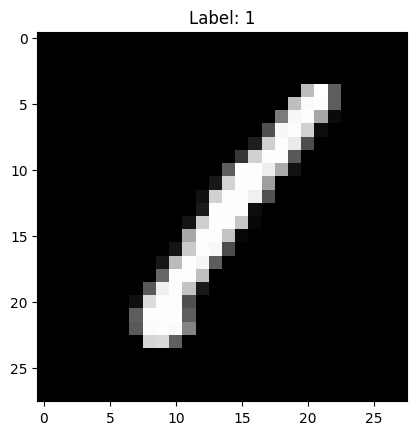

In [7]:
# 观察第一个样本
plt.imshow(X.iloc[0].values.reshape(28, 28), cmap = 'gray')
plt.title(f"Label: {y.iloc[0]}")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, train_size = 0.85
)

In [ ]:
# 多模型对比
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

models = {
    'm0_logist': LogisticRegression(),
    'm1_rfc': RandomForestClassifier(),
    'm2_mlp': MLPClassifier()
}

from sklearn.metrics import accuracy_score

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    acc = accuracy_score(y_valid, y_pred)
    print(f'{name}模型的准确率为{acc:.4f}')

In [ ]:
# MLP超参数优化
from sklearn.model_selection import GridSearchCV
mlp_grid = {
    'hidden_layer_sizes': [(512,)],
    'solver': ['adam'],
    'activation': ['relu'],
    'alpha': [0.01]
}

# 已确定选用参数: relu, (1024,), adam, 0.01
# 中间改动过几次代码（每次只不固定一两个参数）, 以减少成倍增加的运算时间成本

mlp_search = GridSearchCV(
    MLPClassifier(random_state = 42),
    mlp_grid, 
    cv = 3, 
    n_jobs = -1, 
    verbose = 2
)

mlp_search.fit(X_train, y_train)
for i, params in enumerate(mlp_search.cv_results_['params']):
    print(f"第{i + 1}组参数: {params}, 得分: {mlp_search.cv_results_['mean_test_score'][i]:.4f}")
print("最佳参数:", mlp_search.best_params_)
print("验证集准确率:", mlp_search.score(X_valid, y_valid))

In [ ]:
# 训练MLP
model_mlp = MLPClassifier(
    activation = 'relu', 
    hidden_layer_sizes = (512,), 
    solver = 'adam', 
    alpha = 0.01
)

model_mlp = model_mlp.fit(X_train, y_train)
y_proba_mlp_pred = model_mlp.predict_proba(X_valid)

In [ ]:
# 引入CNN进行集成
from keras import layers, Sequential
from keras.callbacks import ReduceLROnPlateau  # 学习率衰减

# 数据转化
X_train_cnn = X_train.values.reshape(-1, 28, 28, 1)  # 4个参数分别是样本数、图片高、图片宽、图片通道数
X_valid_cnn = X_valid.values.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.values.reshape(-1, 28, 28, 1)

# 函数定义
def build_cnn(X_train, X_valid, y_train, y_valid):
    datagen = Sequential([     # 数据增强
        layers.RandomRotation(0.1),  # 随机旋转
        layers.RandomTranslation(0.1, 0.1),  # 随机平移
        layers.RandomZoom(0.1),  # 随机缩放
        layers.RandomShear(0.1)  # 随机剪切
    ])  

    cnn = Sequential([
        layers.Input(shape = (28, 28, 1)),
        datagen,
        
        layers.Conv2D(32, (3, 3), activation = 'relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation = 'relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(64, (3, 3), activation = 'relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation = 'relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Flatten(),
        layers.Dense(512, activation = 'relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation = 'softmax')
    ])

    cnn.compile(   # 编译
        optimizer = 'adam', 
        loss = 'sparse_categorical_crossentropy',   # 稀疏分类交叉熵
        metrics = ['accuracy']
    )

    reduce_lr = ReduceLROnPlateau(   # 学习率衰减
        monitor = 'val_loss', 
        factor = 0.2, 
        patience = 3, 
        min_lr = 0.001
    )

    cnn.fit(
        X_train, y_train,
        batch_size = 128,
        epochs = 10,
        validation_data = (X_valid, y_valid),
        callbacks = [reduce_lr],
        verbose = 1
    )

    return cnn


In [64]:
# CNN 的数据处理
X_train_cnn_train, X_train_cnn_valid, y_train_cnn_train, y_train_cnn_valid = train_test_split(
    X_train_cnn, y_train, test_size = 0.15, random_state = 42
)    # 再划分一道, 用来后续选最佳的alpha

In [65]:
# 训练 CNN
cnn = build_cnn(X_train_cnn_train, X_train_cnn_valid, y_train_cnn_train, y_train_cnn_valid)   

y_proba_cnn_pred = cnn.predict(X_valid_cnn)

Epoch 1/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.7300 - loss: 0.8864 - val_accuracy: 0.1957 - val_loss: 1.9160 - learning_rate: 0.0010
Epoch 2/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.9107 - loss: 0.2816 - val_accuracy: 0.9307 - val_loss: 0.3183 - learning_rate: 0.0010
Epoch 3/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.9395 - loss: 0.1950 - val_accuracy: 0.9565 - val_loss: 0.1328 - learning_rate: 0.0010
Epoch 4/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.9509 - loss: 0.1621 - val_accuracy: 0.9806 - val_loss: 0.0632 - learning_rate: 0.0010
Epoch 5/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.9560 - loss: 0.1377 - val_accuracy: 0.9815 - val_loss: 0.0674 - learning_rate: 0.0010
Epoch 6/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.9638 - loss: 0.1201 - val_accuracy: 0.9808 - val_loss: 0.0687 - learning_rate: 0.0010
Epoch 7/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.9658 - l

In [72]:
# 集成寻找最佳alpha
alphas_acc = [0] * 11
for num in range(11):
    alpha = num * 1.0 / 10

    for i in range(len(y_proba_mlp_pred)):
        pred_list = alpha * y_proba_mlp_pred[i] + (1 - alpha) * y_proba_cnn_pred[i]
        pred = np.argmax(pred_list)
        if pred == y_valid.iloc[i]:
            alphas_acc[num] += 1
    
    alphas_acc[num] *= 1.0 / len(y_valid)
    print(f"在alpha为{alpha}的情况下, 集成模型的准确率是{alphas_acc[num]:.6f}")


cnt_true = 0
alpha = 0.42   # 再精确些
for i in range(len(y_proba_mlp_pred)):
    pred_list = alpha * y_proba_mlp_pred[i] + (1 - alpha) * y_proba_cnn_pred[i]
    pred = np.argmax(pred_list)
    if pred == y_valid.iloc[i]:
        cnt_true += 1

print(f"在alpha为{alpha}的情况下, 集成模型的准确率是{cnt_true * 1.0 / len(y_valid):.6f}")    

# alpha 最佳为 0.42

在alpha为0.0的情况下, 集成模型的准确率是0.986032
在alpha为0.1的情况下, 集成模型的准确率是0.986667
在alpha为0.2的情况下, 集成模型的准确率是0.987460
在alpha为0.3的情况下, 集成模型的准确率是0.987937
在alpha为0.4的情况下, 集成模型的准确率是0.989365
在alpha为0.5的情况下, 集成模型的准确率是0.991746
在alpha为0.6的情况下, 集成模型的准确率是0.989206
在alpha为0.7的情况下, 集成模型的准确率是0.987619
在alpha为0.8的情况下, 集成模型的准确率是0.985873
在alpha为0.9的情况下, 集成模型的准确率是0.984603
在alpha为1.0的情况下, 集成模型的准确率是0.983175
在alpha为0.42的情况下, 集成模型的准确率是0.990000


In [75]:
# 最终模型
y_pred2 = []

# mlp
model_mlp2 = MLPClassifier(
    activation = 'relu', 
    hidden_layer_sizes = (512,), 
    solver = 'adam', 
    alpha = 0.01
)
model_mlp2 = model_mlp2.fit(X, y)
y_proba_mlp_pred2 = model_mlp2.predict_proba(X_test)

# cnn
cnn2 = build_cnn(X_train_cnn, X_valid_cnn, y_train, y_valid)
y_proba_cnn_pred2 = cnn2.predict(X_test_cnn)

alpha = 0.42
for i in range(len(X_test)):
    pred_list = alpha * y_proba_mlp_pred2[i] + (1 - alpha) * y_proba_cnn_pred2[i]
    pred = np.argmax(pred_list)
    y_pred2.append(pred)

Epoch 1/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.7673 - loss: 0.7575 - val_accuracy: 0.0948 - val_loss: 3.0435 - learning_rate: 0.0010
Epoch 2/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - accuracy: 0.9202 - loss: 0.2532 - val_accuracy: 0.9678 - val_loss: 0.1305 - learning_rate: 0.0010
Epoch 3/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 17s 59ms/step - accuracy: 0.9428 - loss: 0.1824 - val_accuracy: 0.9740 - val_loss: 0.0781 - learning_rate: 0.0010
Epoch 4/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.9540 - loss: 0.1471 - val_accuracy: 0.9841 - val_loss: 0.0525 - learning_rate: 0.0010
Epoch 5/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - accuracy: 0.9592 - loss: 0.1315 - val_accuracy: 0.9783 - val_loss: 0.0708 - learning_rate: 0.0010
Epoch 6/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.9638 - loss: 0.1169 - val_accuracy: 0.9756 - val_loss: 0.0725 - learning_rate: 0.0010
Epoch 7/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 17s 59ms/step - accuracy: 0.9678 - l

In [76]:
# 提交
submission = pd.DataFrame({
    'ImageId': sample_submission['ImageId'],
    'Label': y_pred2
})

submission.to_csv('submission.csv', index = False)